### Import packages

In [1]:
import re
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

import warnings

warnings.filterwarnings(
    "ignore",
    category=FutureWarning
)

### Import chunked_paragraphs_with_embeddings_uncer df

In [2]:
chunked_pg_w_embed_uncert = pd.read_csv("data_files/chunked_paragraphs_with_embeddings_uncert.csv")

chunked_pg_w_embed_uncert = chunked_pg_w_embed_uncert[
    chunked_pg_w_embed_uncert["subcategory"].astype(str).str.strip().str.lower()
    ==
    chunked_pg_w_embed_uncert["matched_phrase"].astype(str).str.strip().str.lower()
].copy()

print(chunked_pg_w_embed_uncert["subcategory"].unique())

chunked_pg_w_embed_uncert.head(5)

['Nondefense Discretionary' 'Social Security' 'Medicaid' 'Net Interest'
 'Medicare' 'Other Mandatory' 'Total Discretionary'
 'Defense Discretionary' 'Total Mandatory']


,report_name,paragraph_number,text,subcategory,row_id,match_method,matched_phrase,category,component,contextual_uncertainty_score
0,2000-01-01__12069__The Budget and Economic Out...,10,Dan L. Crippen Director January 2000 This stud...,Nondefense Discretionary,9,direct_phrase_w2v_neighbors,Nondefense Discretionary,Discretionary,outlay,0.022607
6,2000-01-01__12069__The Budget and Economic Out...,19,"Regardless of the variant, the budgetary pictu...",Social Security,18,direct_phrase_w2v_neighbors,Social Security,Mandatory,outlay,0.021429
28,2000-01-01__12069__The Budget and Economic Out...,49,Discretionary spending is projected to increas...,Nondefense Discretionary,48,direct_phrase_w2v_neighbors,Nondefense Discretionary,Discretionary,outlay,0.016471
40,2000-01-01__12069__The Budget and Economic Out...,83,To illustrate the possible effects of differen...,Medicaid,82,direct_phrase_w2v_neighbors,Medicaid,Mandatory,outlay,0.092086
46,2000-01-01__12069__The Budget and Economic Out...,89,CBO’s latest budget outlook is considerably mo...,Net Interest,88,direct_phrase_w2v_neighbors,Net Interest,Net Interest,outlay,0.019937


### Import CBO projection errors df from GitHub 

In [3]:
proj_errors = pd.read_csv("https://raw.githubusercontent.com/US-CBO/eval-projections/main/output_data/outlay_projection_errors.csv")
proj_errors["abs_projection_error"] = proj_errors["projection_error"].abs()


### Merge chunked_pg_w_embed_uncert and proj_errors

In [4]:
# 1. Parse the Baseline Year from the CBO GitHub DataFrame
# Using errors='coerce' to safely handle formatting and .dt.year to isolate the Year
proj_errors['temp_baseline_dt'] = pd.to_datetime(proj_errors['baseline_date'], errors='coerce')
proj_errors['baseline_year'] = proj_errors['temp_baseline_dt'].dt.year

# 2. Extract the Publication Year from your updated uncertainty DataFrame
# Extract 'YYYY' directly from the start of the 'report_name' string using regex
year_pattern = r'^(\d{4})'
chunked_pg_w_embed_uncert['report_year'] = chunked_pg_w_embed_uncert['report_name'].str.extract(year_pattern)[0]

# Convert report_year to numeric/integer to ensure clean data types for merging
chunked_pg_w_embed_uncert['report_year'] = pd.to_numeric(chunked_pg_w_embed_uncert['report_year'], errors='coerce')

# 3. Clean up the subcategory strings to prevent case-sensitivity or whitespace match failures
proj_errors['subcategory'] = proj_errors['subcategory'].astype(str).str.strip().str.lower()
chunked_pg_w_embed_uncert['subcategory'] = chunked_pg_w_embed_uncert['subcategory'].astype(str).str.strip().str.lower()

# 4. Perform the Merge on Year and Subcategory
# Matching 'report_year' from uncertainty to 'baseline_year' from the GitHub errors
merged_df = pd.merge(
    chunked_pg_w_embed_uncert,
    proj_errors[['baseline_year', 'subcategory', 'projected_fiscal_year', 'abs_projection_error']],
    left_on=['report_year', 'subcategory'],
    right_on=['baseline_year', 'subcategory'],
    how='inner'  # Swap to 'left' if you want to keep text chunks without error metrics
)

# 5. Calculate the Forecast Horizon Column (Year Difference)
merged_df['projected_fiscal_year'] = pd.to_numeric(merged_df['projected_fiscal_year'], errors='coerce')

# Horizon = Target Projection Year - Baseline Publication Year
merged_df['projection_horizon_years'] = merged_df['projected_fiscal_year'] - merged_df['report_year']

# 6. Post-Merge Clean Up
# Added errors='ignore' so it won't crash if your update removed/changed these columns
columns_to_drop = ['baseline_year', 'extracted_date', 'temp_datetime', 'year_month_key']
merged_df = merged_df.drop(columns=columns_to_drop, errors='ignore')

# Display a preview of the clean structure
print(f"Merge complete. Row count: {len(merged_df)}")
merged_df[['report_name', 'subcategory', 'projected_fiscal_year', 'projection_horizon_years', 'abs_projection_error']].head()


Merge complete. Row count: 36088


,report_name,subcategory,projected_fiscal_year,projection_horizon_years,abs_projection_error
0,2000-01-01__12069__The Budget and Economic Out...,nondefense discretionary,2000,0,13.415
1,2000-01-01__12069__The Budget and Economic Out...,nondefense discretionary,2001,1,4.696
2,2000-01-01__12069__The Budget and Economic Out...,nondefense discretionary,2002,2,2.649
3,2000-01-01__12069__The Budget and Economic Out...,nondefense discretionary,2003,3,6.871
4,2000-01-01__12069__The Budget and Economic Out...,nondefense discretionary,2004,4,12.100


In [5]:
# Drop any subcategory that contains "total" case-insensitive
mask_drop = merged_df["subcategory"].astype(str).str.contains(
    "total",
    case=False,
    na=False,
    regex=False
)

merged_df = merged_df[~mask_drop].copy()

# Check remaining subcategories
merged_df["subcategory"].unique()

merged_df.to_csv("data_files/projection_error_uncertainty.csv", index=False)

In [6]:
# Correlation coefficient for each subcategory
# 1. Drop rows missing either the uncertainty score or projection error
clean_df = merged_df[['subcategory', 'contextual_uncertainty_score', 'abs_projection_error']].dropna()

# 2. Group by subcategory and calculate Spearman correlation for each
sub_results = []

for subcat, group in clean_df.groupby('subcategory'):
    n_samples = len(group)
    
    # We need at least 3 data points to calculate a correlation coefficient
    if n_samples >= 3:
        coef, p_val = stats.spearmanr(group['contextual_uncertainty_score'], group['abs_projection_error'])
    else:
        coef, p_val = None, None
        
    sub_results.append({
        'subcategory': subcat,
        'sample_size': n_samples,
        'spearman_rho': coef,
        'p_value': p_val
    })

# 3. Convert results into a structured DataFrame
subcategory_correlations = pd.DataFrame(sub_results)

# 4. Add a quick visual indicator for statistical significance
def check_sig(p):
    if p is None:
        return 'Too few samples (<3)'
    elif p < 0.01:
        return 'Highly Significant (p < 0.01) **'
    elif p < 0.05:
        return 'Significant (p < 0.05) *'
    else:
        return 'Not Significant'

subcategory_correlations['significance'] = subcategory_correlations['p_value'].apply(check_sig)

# 5. Sort by the strongest absolute correlations first
subcategory_correlations['abs_rho'] = subcategory_correlations['spearman_rho'].abs()
subcategory_correlations = (
    subcategory_correlations
    .sort_values(by='abs_rho', ascending=False)
    .drop(columns=['abs_rho'])
    .reset_index(drop=True)
)

# Display the final summary table
subcategory_correlations

,subcategory,sample_size,spearman_rho,p_value,significance
0,medicaid,3715,-0.087941,7.931067e-08,Highly Significant (p < 0.01) **
1,medicare,4188,0.082818,7.996803e-08,Highly Significant (p < 0.01) **
2,net interest,6490,-0.034358,5.637584e-03,Highly Significant (p < 0.01) **
3,other mandatory,1758,0.022183,3.526061e-01,Not Significant
4,nondefense discretionary,2468,0.011966,5.524085e-01,Not Significant
5,social security,15822,-0.011211,1.585096e-01,Not Significant
6,defense discretionary,278,0.000574,9.923921e-01,Not Significant


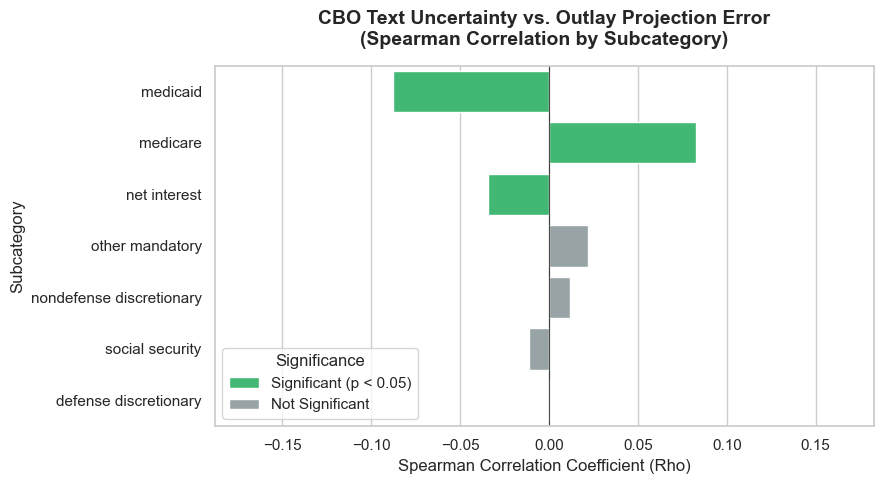

In [7]:
# Visualize the correlations for each subcategory above
# 1. Prepare your data for visualization
# Filter out any subcategories that didn't have enough samples to calculate correlation
viz_df = subcategory_correlations.dropna(subset=['spearman_rho']).copy()

# Sort by the strength of the correlation (absolute value) so the strongest relationships are at the top
viz_df['abs_rho'] = viz_df['spearman_rho'].abs()
viz_df = viz_df.sort_values(by='abs_rho', ascending=False)

# Add a grouping column specifically for plotting color schemes
viz_df['Significance'] = viz_df['p_value'].apply(
    lambda p: 'Significant (p < 0.05)' if p < 0.05 else 'Not Significant'
)

# 2. Set up the plotting canvas
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))

# 3. Create a horizontal barplot
# Greens signify reliable signals; Greys signify no reliable relationship.
sns.barplot(
    data=viz_df,
    x='spearman_rho',
    y='subcategory',
    hue='Significance',
    palette={
        'Significant (p < 0.05)': '#2ecc71',  # Clear emerald green
        'Not Significant': '#95a5a6'          # Muted slate grey
    },
    dodge=False
)

# 4. Enhance the chart details
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.7)  # Zero correlation reference line
plt.title('CBO Text Uncertainty vs. Outlay Projection Error\n(Spearman Correlation by Subcategory)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Spearman Correlation Coefficient (Rho)', fontsize=12)
plt.ylabel('Subcategory', fontsize=12)

# Adjust the x-axis limits to leave a little breathing room
min_val = viz_df['spearman_rho'].min()
max_val = viz_df['spearman_rho'].max()
plt.xlim(min_val - 0.1 if min_val < 0 else -0.1, max_val + 0.1 if max_val > 0 else 0.1)

plt.tight_layout()
plt.show()

In [8]:
subs = ['medicaid','medicare','net interest']

def plot_uncertainty_vs_error_by_forecast_year_from_merged(
    merged_df,
    program="medicaid",
    horizons=(3, 6, 9),
    score_col="contextual_uncertainty_score",
    err_col="abs_projection_error",
    show_uncertainty_as_percent=True,
    year_tick_step=2,
):
    d0 = merged_df.copy()

    # normalize labels
    d0["subcategory"] = d0["subcategory"].astype(str).str.strip().str.lower()
    program = str(program).strip().lower()

    # filter
    d0 = d0[d0["subcategory"].eq(program)].copy()
    d0 = d0.dropna(subset=["report_year", score_col, err_col, "projection_horizon_years"])

    d0["report_year"] = pd.to_numeric(d0["report_year"], errors="coerce")
    d0["projection_horizon_years"] = pd.to_numeric(d0["projection_horizon_years"], errors="coerce")
    d0 = d0.dropna(subset=["report_year", "projection_horizon_years"])

    d0["report_year"] = d0["report_year"].astype(int)
    d0["projection_horizon_years"] = d0["projection_horizon_years"].astype(int)

    # NEW: forecast year (year being forecast / realized)
    d0["forecast_year"] = d0["report_year"] + d0["projection_horizon_years"]

    fig, axes = plt.subplots(1, len(horizons), figsize=(18, 5), sharex=False)
    if len(horizons) == 1:
        axes = [axes]

    # formatters
    unc_fmt = FuncFormatter(lambda y, _: f"{100*y:.1f}%") if show_uncertainty_as_percent else FuncFormatter(lambda y, _: f"{y:.3f}")
    err_fmt = FuncFormatter(lambda y, _: f"{y:,.0f}")

    for i, H in enumerate(horizons):
        ax = axes[i]

        d = d0[d0["projection_horizon_years"].eq(H)].copy()
        if d.empty:
            ax.set_title(f"{program.title()}: Horizon {H} (no data)")
            ax.axis("off")
            continue

        # Aggregate to FORECAST YEAR (not report year)
        plot_df = (
            d.groupby("forecast_year", as_index=False)
             .agg(
                 mean_uncertainty=(score_col, "mean"),
                 paragraph_count=(score_col, "size"),
                 abs_projection_error=(err_col, "mean"),
                 mean_baseline_year=("report_year", "mean"),  # for debugging/interpretation
             )
             .sort_values("forecast_year")
        )

        # Left axis: uncertainty
        ax.plot(plot_df["forecast_year"], plot_df["mean_uncertainty"],
                marker="o", linewidth=2, color="#1f77b4")
        ax.set_title(f"{program.title()}: {H}-year horizon\n(x-axis = Forecast year)")
        ax.set_xlabel("Forecast year (year being projected / realized)")
        if i == 0:
            ax.set_ylabel("Mean uncertainty", color="#1f77b4")
        ax.tick_params(axis="y", labelcolor="#1f77b4")
        ax.yaxis.set_major_formatter(unc_fmt)
        ax.grid(True, linestyle="--", alpha=0.35)

        # X ticks
        years = plot_df["forecast_year"].to_numpy()
        if len(years) > 0:
            start = int(years.min())
            end = int(years.max())
            ax.set_xticks(list(range(start, end + 1, year_tick_step)))
        ax.tick_params(axis="x", rotation=45)

        # Right axis: abs error
        ax2 = ax.twinx()
        ax2.plot(plot_df["forecast_year"], plot_df["abs_projection_error"],
                 marker="s", linewidth=2, color="#d62728")
        if i == len(horizons) - 1:
            ax2.set_ylabel("Absolute projection error", color="#d62728")
        ax2.tick_params(axis="y", labelcolor="#d62728")
        ax2.yaxis.set_major_formatter(err_fmt)

    plt.tight_layout()
    plt.show()

for sub in subs:

    # Medicaid
    plot_uncertainty_vs_error_by_forecast_year_from_merged(
        merged_df=merged_df, program=sub, horizons=horizons, show_uncertainty_as_percent=True
    )
    


NameError: name 'subs' is not defined